# Pull Data

## Imports

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('.')

from functions.fn_clean import (
    drop_structural_columns,
    fix_column_types,
    impute_column,
    cap_outliers_iqr,
    transform_skewed_column,
    bin_rare_categories,
    merge_tables,
)
from functions.fn_explore import (
    summarize_dataframe,
    describe_column,
    rank_features_for_target,
    get_correlation_matrix,
    test_relationship,
    compute_target_rate_by_category,
)
from functions.fn_plot import (
    plot_missing_heatmap,
    plot_distributions_all,
    plot_distribution,
    plot_target_rate,
    plot_scatter,
    plot_boxplot,
    plot_correlation_heatmap,
    plot_bivariate_summary,
)

## Load Raw Data

In [58]:
# Six tables feed into the resident pipeline.
# Unit of analysis: ONE ROW PER RESIDENT.
# All other tables will be aggregated down to resident-level features.

residents    = pd.read_csv('data/residents.csv')
health       = pd.read_csv('data/health_wellbeing_records.csv')
education    = pd.read_csv('data/education_records.csv')
counseling   = pd.read_csv('data/process_recordings.csv')
incidents    = pd.read_csv('data/incident_reports.csv')
visitations  = pd.read_csv('data/home_visitations.csv')
interventions = pd.read_csv('data/intervention_plans.csv')

print(f"residents:     {residents.shape}")
print(f"health:        {health.shape}")
print(f"education:     {education.shape}")
print(f"counseling:    {counseling.shape}")
print(f"incidents:     {incidents.shape}")
print(f"visitations:   {visitations.shape}")
print(f"interventions: {interventions.shape}")

residents:     (60, 49)
health:        (534, 14)
education:     (534, 10)
counseling:    (2819, 15)
incidents:     (100, 12)
visitations:   (1337, 14)
interventions: (180, 11)


## First Look

In [59]:
print(residents.dtypes)
print()
print(residents.info())

resident_id                   int64
case_control_no                 str
internal_code                   str
safehouse_id                  int64
case_status                     str
sex                             str
date_of_birth                   str
birth_status                    str
place_of_birth                  str
religion                        str
case_category                   str
sub_cat_orphaned               bool
sub_cat_trafficked             bool
sub_cat_child_labor            bool
sub_cat_physical_abuse         bool
sub_cat_sexual_abuse           bool
sub_cat_osaec                  bool
sub_cat_cicl                   bool
sub_cat_at_risk                bool
sub_cat_street_child           bool
sub_cat_child_with_hiv         bool
is_pwd                         bool
pwd_type                        str
has_special_needs              bool
special_needs_diagnosis         str
family_is_4ps                  bool
family_solo_parent             bool
family_indigenous           

# Univariate Summary

## Full Univariate Summary

In [60]:
# The residents table is wide — 40+ columns.
# Key things to watch for:
#   - age_upon_admission, present_age, length_of_stay: stored as strings
#     like "13 Years 2 months" — needs parsing
#   - pwd_type, special_needs_diagnosis: intentional nulls (only populated
#     if is_pwd/has_special_needs is True)
#   - reintegration_type, reintegration_status: null for residents not yet
#     in a reintegration pathway — intentional
#   - notes_restricted: free text, always drop
#   - sex: all 'F' — zero variance, always drop
#   - place_of_birth, referring_agency_person: high cardinality free text

num_df, cat_df = summarize_dataframe(residents)


  NUMERIC COLUMNS (3)
                    dtype  count  missing  missing_pct  min   max   mean  median      std    skew    kurt
column                                                                                                   
resident_id         int64     60        0          0.0  1.0  60.0  30.50    30.5  17.4642  0.0000 -1.2000
safehouse_id        int64     60        0          0.0  1.0   9.0   4.35     4.0   2.4895  0.1915 -1.2245
notes_restricted  float64      0       60        100.0  NaN   NaN    NaN     NaN      NaN     NaN     NaN

  CATEGORICAL COLUMNS (46)
                         dtype  count  missing  missing_pct  unique                 mode
column                                                                                  
case_control_no            str     60        0         0.00      60                C0043
internal_code              str     60        0         0.00      60              LS-0001
case_status                str     60        0         0.00    

## Missing Value Map

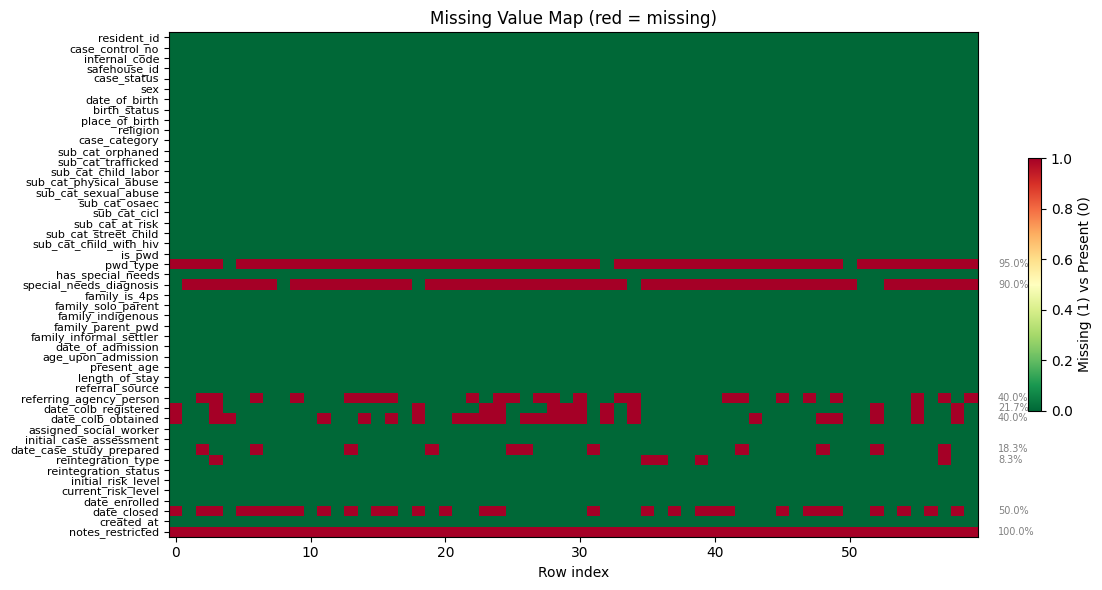

In [61]:
# Expect structural null bands for:
#   pwd_type: null when is_pwd is False
#   special_needs_diagnosis: null when has_special_needs is False
#   reintegration_type / reintegration_status: null for non-reintegrating residents
#   date_colb_registered / date_colb_obtained: nullable administrative dates
#   date_case_study_prepared: nullable
#   date_closed: null for still-active cases

plot_missing_heatmap(residents)

## Data Cleaning

### Drop Structural Columns

In [62]:
# Drop columns that can never be model features:
residents = drop_structural_columns(residents, [
    'case_control_no',          # administrative ID
    'internal_code',            # administrative ID
    'sex',                      # all 'F' — zero variance
    'place_of_birth',           # high-cardinality free text
    'referring_agency_person',  # free text name
    'assigned_social_worker',   # free text name
    'initial_case_assessment',  # free text narrative
    'notes_restricted',         # restricted free text
    'date_enrolled',            # duplicate of date_of_admission
    # COLB dates: administrative paperwork dates, not predictive of outcomes
    'date_colb_registered',
    'date_colb_obtained',
    'date_case_study_prepared',
])

print(f"Shape after dropping: {residents.shape}")

[drop_structural_columns] Dropped 12 columns: ['case_control_no', 'internal_code', 'sex', 'place_of_birth', 'referring_agency_person', 'assigned_social_worker', 'initial_case_assessment', 'notes_restricted', 'date_enrolled', 'date_colb_registered', 'date_colb_obtained', 'date_case_study_prepared']
Shape after dropping: (60, 37)


### Fix Types and Parse Dates

In [63]:
residents = fix_column_types(residents)

# Parse core date columns
for col in ['date_of_birth', 'date_of_admission', 'date_closed', 'created_at']:
    residents[col] = pd.to_datetime(residents[col], errors='coerce')

ref_date = pd.Timestamp('today').normalize()

# Age at admission in days — more precise than the string field
residents['age_at_admission_days'] = (
    residents['date_of_admission'] - residents['date_of_birth']
).dt.days

# Days in care — how long they've been in the system
residents['days_in_care'] = (
    ref_date - residents['date_of_admission']
).dt.days

# For closed cases: actual length of stay in days
residents['length_of_stay_days'] = (
    residents['date_closed'] - residents['date_of_admission']
).dt.days

# Drop raw date columns after extracting what we need
residents = residents.drop(columns=[
    'date_of_birth',
    'date_of_admission',
    'date_closed',
    'created_at',
    # String versions of age/stay — inaccurate per data dictionary
    'age_upon_admission',
    'present_age',
    'length_of_stay',
])

print("Engineered: age_at_admission_days, days_in_care, length_of_stay_days")
print(residents[['age_at_admission_days', 'days_in_care', 'length_of_stay_days']].describe())

Engineered: age_at_admission_days, days_in_care, length_of_stay_days
       age_at_admission_days  days_in_care  length_of_stay_days
count              60.000000     60.000000            30.000000
mean             5078.233333    782.600000           445.100000
std              1018.533681    250.039265           162.419073
min              3201.000000    367.000000           191.000000
25%              4390.000000    554.750000           286.750000
50%              5439.500000    805.500000           431.000000
75%              5545.750000    991.500000           583.000000
max              6465.000000   1185.000000           697.000000


### Handle Structural Nulls in Residents

In [64]:
# pwd_type and special_needs_diagnosis: null when the flag is False
residents['pwd_type'] = residents['pwd_type'].fillna('None')
residents['special_needs_diagnosis'] = residents['special_needs_diagnosis'].fillna('None')

# reintegration_type / reintegration_status: null for residents not yet
# in any reintegration pathway
residents['reintegration_type']   = residents['reintegration_type'].fillna('None')
residents['reintegration_status'] = residents['reintegration_status'].fillna('Not Started')

# length_of_stay_days: null for still-active cases (no date_closed)
# Fill with days_in_care as the best proxy for current stay length
residents['length_of_stay_days'] = residents['length_of_stay_days'].fillna(
    residents['days_in_care']
)

print(residents.isnull().sum()[residents.isnull().sum() > 0])

Series([], dtype: int64)


## Engineer Risk Target

In [65]:
# Target: risk_escalated
# Did this resident's risk level get WORSE from intake to present?
# This is the "falling through the cracks" question from the project brief.
# True if current_risk_level is higher severity than initial_risk_level.

risk_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

residents['initial_risk_num'] = residents['initial_risk_level'].map(risk_order)
residents['current_risk_num'] = residents['current_risk_level'].map(risk_order)

residents['risk_escalated'] = (
    residents['current_risk_num'] > residents['initial_risk_num']
).astype(int)

print(f"risk_escalated: {residents['risk_escalated'].sum()} residents "
      f"({residents['risk_escalated'].mean():.1%})")
print(f"\nInitial risk distribution:\n{residents['initial_risk_level'].value_counts()}")
print(f"\nCurrent risk distribution:\n{residents['current_risk_level'].value_counts()}")

risk_escalated: 6 residents (10.0%)

Initial risk distribution:
initial_risk_level
Medium      24
High        17
Low         14
Critical     5
Name: count, dtype: int64

Current risk distribution:
current_risk_level
Low         30
Medium      18
High        10
Critical     2
Name: count, dtype: int64


### Engineer Reintegration Target

In [66]:
# Target: reintegration_achieved
# Binary: has this resident completed reintegration?
# Directly answers "which residents are ready / have succeeded?"

residents['reintegration_achieved'] = (
    residents['reintegration_status'] == 'Completed'
).astype(int)

print(f"reintegration_achieved: {residents['reintegration_achieved'].sum()} residents "
      f"({residents['reintegration_achieved'].mean():.1%})")

reintegration_achieved: 19 residents (31.7%)


## Aggregate Records

### Aggregate Health Records

In [67]:
# Aggregate monthly health records to one row per resident.
# Use the MOST RECENT record for point-in-time features,
# and AVERAGES for trend-based features.

health['record_date'] = pd.to_datetime(health['record_date'], errors='coerce')

# Most recent health record per resident
health_latest = (
    health.sort_values('record_date')
    .groupby('resident_id')
    .last()
    .reset_index()
    [['resident_id', 'general_health_score', 'nutrition_score',
      'sleep_quality_score', 'energy_level_score', 'bmi']]
    .rename(columns={
        'general_health_score': 'health_score_latest',
        'nutrition_score':      'nutrition_score_latest',
        'sleep_quality_score':  'sleep_score_latest',
        'energy_level_score':   'energy_score_latest',
        'bmi':                  'bmi_latest',
    })
)

# Average scores across all records (captures trend, not just snapshot)
health_avg = (
    health.groupby('resident_id')
    .agg(
        health_score_avg    =('general_health_score', 'mean'),
        health_record_count =('health_record_id',     'count'),
        checkup_completion  =('medical_checkup_done', 'mean'),
    )
    .reset_index()
)

# Join both
health_agg = merge_tables(health_latest, health_avg, on='resident_id', how='left')
print(f"Health aggregated: {health_agg.shape}")
health_agg.head()

[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
Health aggregated: (60, 9)


,resident_id,health_score_latest,nutrition_score_latest,sleep_score_latest,energy_score_latest,bmi_latest,health_score_avg,health_record_count,checkup_completion
0,1,3.22,3.39,3.20,2.91,15.8,3.103333,6,0.500000
1,2,3.62,3.67,3.40,3.08,18.4,3.449000,10,0.700000
2,3,3.57,3.39,3.07,3.58,17.2,3.181818,11,0.454545
3,4,3.11,3.10,2.82,3.11,17.2,3.157273,11,0.454545
4,5,3.06,3.28,3.01,3.18,17.2,3.087778,9,0.888889


### Aggregate Education Records

In [68]:
education['record_date'] = pd.to_datetime(education['record_date'], errors='coerce')

# Most recent education record per resident
edu_latest = (
    education.sort_values('record_date')
    .groupby('resident_id')
    .last()
    .reset_index()
    [['resident_id', 'attendance_rate', 'progress_percent',
      'education_level', 'enrollment_status', 'completion_status']]
    .rename(columns={
        'attendance_rate':    'attendance_rate_latest',
        'progress_percent':   'progress_percent_latest',
        'education_level':    'education_level_latest',
        'enrollment_status':  'enrollment_status_latest',
        'completion_status':  'completion_status_latest',
    })
)

# Average progress over time
edu_avg = (
    education.groupby('resident_id')
    .agg(
        progress_avg        =('progress_percent', 'mean'),
        attendance_avg      =('attendance_rate',  'mean'),
        education_records   =('education_record_id', 'count'),
    )
    .reset_index()
)

edu_agg = merge_tables(edu_latest, edu_avg, on='resident_id', how='left')
print(f"Education aggregated: {edu_agg.shape}")

[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
Education aggregated: (60, 9)


### Aggregate Counseling Records

In [69]:
# Counseling sessions tell us about emotional trajectory and engagement
counseling['session_date'] = pd.to_datetime(counseling['session_date'], errors='coerce')

counseling_agg = (
    counseling.groupby('resident_id')
    .agg(
        session_count           =('recording_id',         'count'),
        avg_session_duration    =('session_duration_minutes', 'mean'),
        progress_rate           =('progress_noted',       'mean'),  # % sessions with progress
        concern_rate            =('concerns_flagged',     'mean'),  # % sessions with concerns
        referral_rate           =('referral_made',        'mean'),  # % sessions with referral
    )
    .reset_index()
)

print(f"Counseling aggregated: {counseling_agg.shape}")

Counseling aggregated: (60, 6)


### Aggregate Incident Reports

In [70]:
# Incidents are signals of regression or risk escalation
incidents['incident_date'] = pd.to_datetime(incidents['incident_date'], errors='coerce')

severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
incidents['severity_num'] = incidents['severity'].map(severity_map)

incidents_agg = (
    incidents.groupby('resident_id')
    .agg(
        incident_count       =('incident_id',    'count'),
        avg_severity         =('severity_num',   'mean'),
        high_severity_count  =('severity_num',   lambda x: (x == 3).sum()),
        runaway_attempts     =('incident_type',  lambda x: (x == 'RunawayAttempt').sum()),
        self_harm_incidents  =('incident_type',  lambda x: (x == 'SelfHarm').sum()),
    )
    .reset_index()
)

print(f"Incidents aggregated: {incidents_agg.shape}")

Incidents aggregated: (44, 6)


### Aggregate Home Visitations

In [71]:
# Visitations tell us about family cooperation and home safety
visitations_agg = (
    visitations.groupby('resident_id')
    .agg(
        visitation_count         =('visitation_id',           'count'),
        safety_concern_rate      =('safety_concerns_noted',   'mean'),
        favorable_outcome_rate   =('visit_outcome',
                                   lambda x: (x == 'Favorable').sum() / len(x)),
        family_cooperation_score =('family_cooperation_level',
                                   lambda x: x.map({
                                       'Highly Cooperative': 4,
                                       'Cooperative': 3,
                                       'Neutral': 2,
                                       'Uncooperative': 1
                                   }).mean()),
    )
    .reset_index()
)

print(f"Visitations aggregated: {visitations_agg.shape}")

Visitations aggregated: (58, 5)


### Aggregate Intervention Plans

In [72]:
# Interventions tell us about case complexity and goal progress
interventions_agg = (
    interventions.groupby('resident_id')
    .agg(
        total_plans         =('plan_id',       'count'),
        achieved_plans      =('status',        lambda x: (x == 'Achieved').sum()),
        open_plans          =('status',        lambda x: (x == 'Open').sum()),
        plan_categories     =('plan_category', 'nunique'),
    )
    .reset_index()
)

# Achievement rate: what % of their plans have been completed?
interventions_agg['plan_achievement_rate'] = (
    interventions_agg['achieved_plans'] / interventions_agg['total_plans']
).fillna(0)

print(f"Interventions aggregated: {interventions_agg.shape}")

Interventions aggregated: (60, 6)


### Build the Master Resident DataFrame

In [73]:
# Join all aggregated tables onto the base residents table.
# All joins are LEFT so every resident is preserved even if they have
# no records in a given table yet.

df = residents.copy()

for name, agg_df in [
    ('health',        health_agg),
    ('education',     edu_agg),
    ('counseling',    counseling_agg),
    ('incidents',     incidents_agg),
    ('visitations',   visitations_agg),
    ('interventions', interventions_agg),
]:
    df = merge_tables(df, agg_df, on='resident_id', how='left')
    print(f"After {name} join: {df.shape}")

df = df.drop(columns=['resident_id'])
print(f"\nFinal shape: {df.shape}")

[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After health join: (60, 45)
[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After education join: (60, 53)
[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After counseling join: (60, 58)
[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After incidents join: (60, 63)
[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After visitations join: (60, 67)
[merge_tables] LEFT JOIN on 'resident_id': 60 rows → 60 rows
After interventions join: (60, 72)

Final shape: (60, 71)


### Fill Zeros for Missing Aggregates

In [74]:
# Residents with no records in a given table get NaN after the join.
# For count-based features, 0 is the correct fill.
# For rate-based features, a neutral value (0.5 or 0) makes sense.

count_cols = [
    'session_count', 'incident_count', 'visitation_count',
    'total_plans', 'achieved_plans', 'open_plans', 'plan_categories',
    'health_record_count', 'education_records',
    'high_severity_count', 'runaway_attempts', 'self_harm_incidents',
]
rate_cols = [
    'progress_rate', 'concern_rate', 'referral_rate',
    'safety_concern_rate', 'favorable_outcome_rate', 'plan_achievement_rate',
    'checkup_completion', 'attendance_avg', 'attendance_rate_latest',
]
score_cols = [
    'health_score_latest', 'nutrition_score_latest', 'sleep_score_latest',
    'energy_score_latest', 'bmi_latest', 'health_score_avg',
    'avg_session_duration', 'avg_severity', 'family_cooperation_score',
    'progress_percent_latest', 'progress_avg',
]

for col in count_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

for col in rate_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Score columns: fill with median (a resident with no health records
# shouldn't be assumed healthy or unhealthy)
for col in score_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Nulls remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulls remaining:
Series([], dtype: int64)


## Impute and Bin Remaining Columns

In [75]:
# Check what's left
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining if len(remaining) > 0 else "No remaining nulls.")

No remaining nulls.


In [76]:
# Check categorical value distributions and bin rare categories
for col in ['religion', 'case_category', 'referral_source',
            'initial_risk_level', 'current_risk_level']:
    if col in df.columns:
        counts = df[col].value_counts(normalize=True).round(3)
        print(f"\n{col}:\n{counts.to_string()}")


religion:
religion
Evangelical              0.200
Seventh-day Adventist    0.150
Buddhism                 0.133
Unspecified              0.117
Islam                    0.117
Roman Catholic           0.100
Jehovah's Witness        0.100
Other                    0.083

case_category:
case_category
Surrendered    0.350
Abandoned      0.300
Foundling      0.183
Neglected      0.167

referral_source:
referral_source
Government Agency    0.267
Court Order          0.167
Police               0.167
Community            0.150
Self-Referral        0.133
NGO                  0.117

initial_risk_level:
initial_risk_level
Medium      0.400
High        0.283
Low         0.233
Critical    0.083

current_risk_level:
current_risk_level
Low         0.500
Medium      0.300
High        0.167
Critical    0.033


In [77]:
# Bin rare categories if needed based on output above
df = bin_rare_categories(df, 'religion',        threshold=0.05)
df = bin_rare_categories(df, 'place_of_birth',  threshold=0.05) if 'place_of_birth' in df.columns else df

[bin_rare_categories] 'religion' — no rare categories at 5.0% threshold.


## Final Null Check and Shape

print(f"Final shape: {df.shape}")
print(f"\nAny nulls remaining:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "None.")

print(f"\nTarget summary:")
print(f"  risk_escalated:         {df['risk_escalated'].mean():.1%} positive")
print(f"  reintegration_achieved: {df['reintegration_achieved'].mean():.1%} positive")
print(f"  progress_percent_latest mean: {df['progress_percent_latest'].mean():.1f}")

# Bivariate

## Risk Escalation


  BIVARIATE SUMMARY — target: 'risk_escalated'




  TOP FEATURES FOR 'risk_escalated' (p < 0.05)
                 feature    test      metric  p_value
      current_risk_level   ANOVA F = 14.9333 0.000000
completion_status_latest   ANOVA  F = 5.3857 0.023840
      family_solo_parent   ANOVA  F = 4.6400 0.035402
        current_risk_num Pearson  r = 0.5596 0.000003
 progress_percent_latest Pearson r = -0.3478 0.006465
        sub_cat_orphaned   ANOVA F = -0.0000      NaN


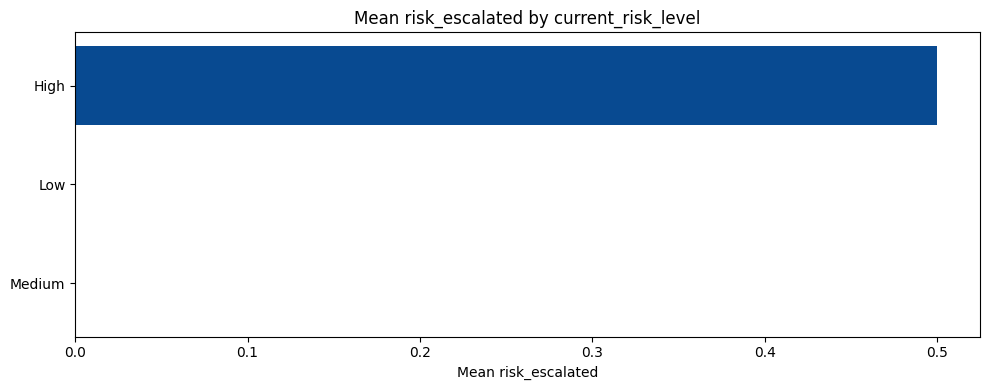

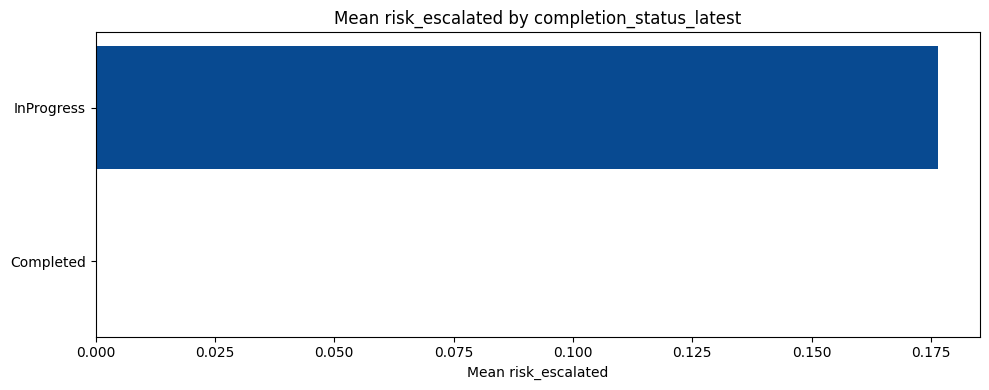

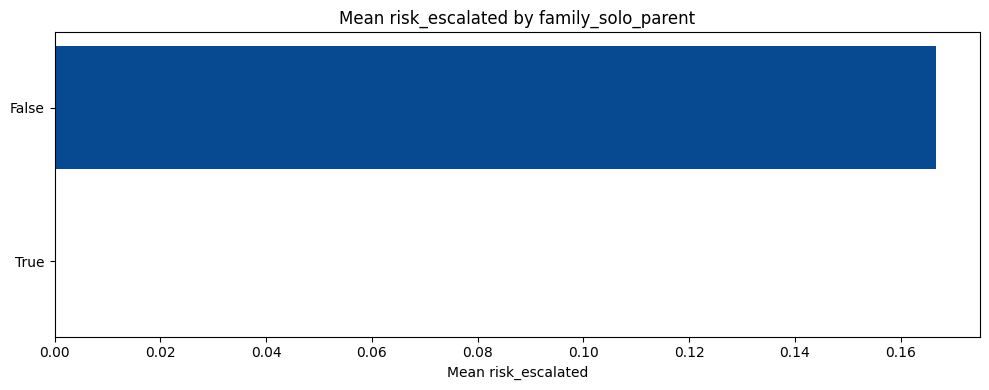

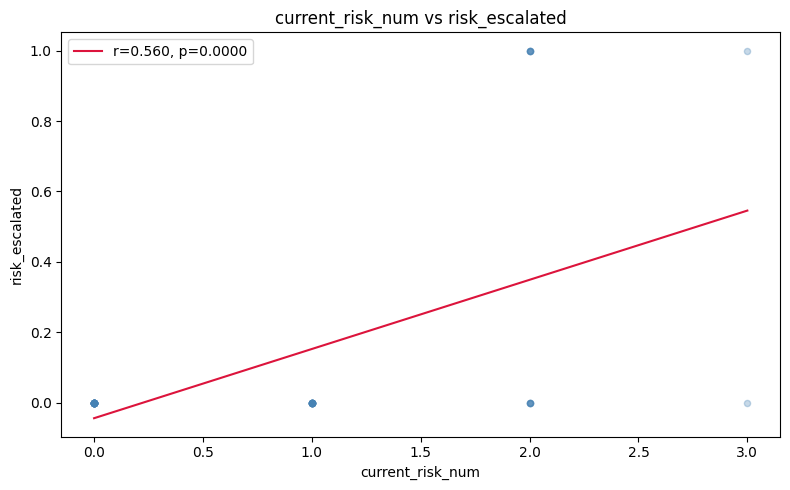

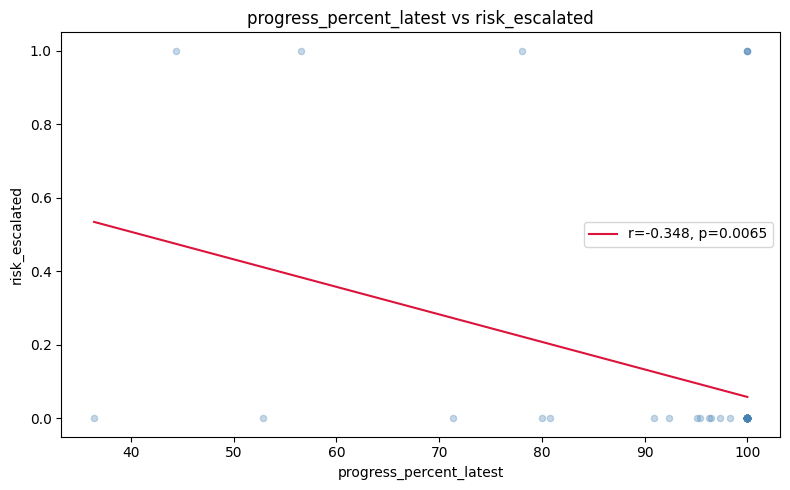

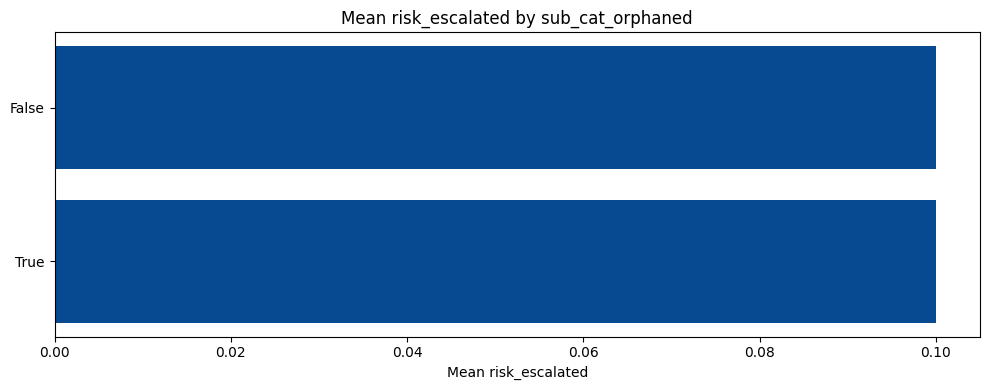

In [78]:
# What predicts whether a resident's risk level gets worse?
# This is the "falling through the cracks" detector.
# Look for: incident counts, concern rates, family cooperation, health scores.

plot_bivariate_summary(df, target='risk_escalated', top_n=15)

## Reintegration Achieved


  BIVARIATE SUMMARY — target: 'reintegration_achieved'


  TOP FEATURES FOR 'reintegration_achieved' (p < 0.05)
                 feature    test     metric  p_value
    reintegration_status   ANOVA    F = inf 0.000000
completion_status_latest   ANOVA F = 5.9955 0.017387
        visitation_count Pearson r = 0.3210 0.012391
            days_in_care Pearson r = 0.2898 0.024698
        runaway_attempts Pearson r = 0.2585 0.046083


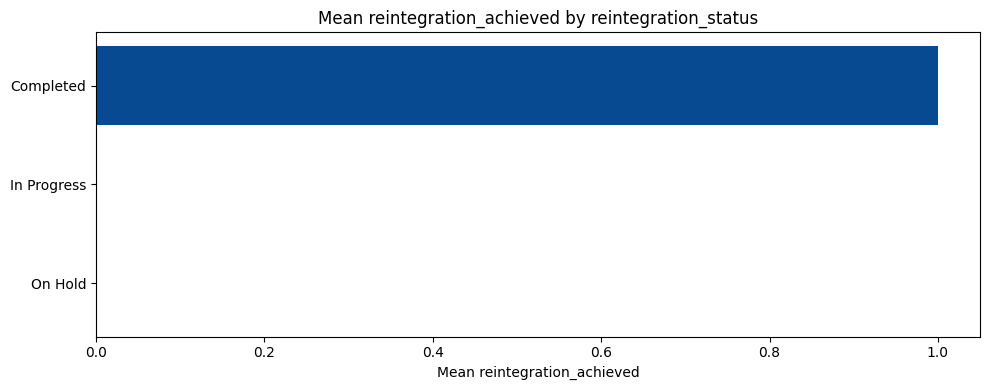

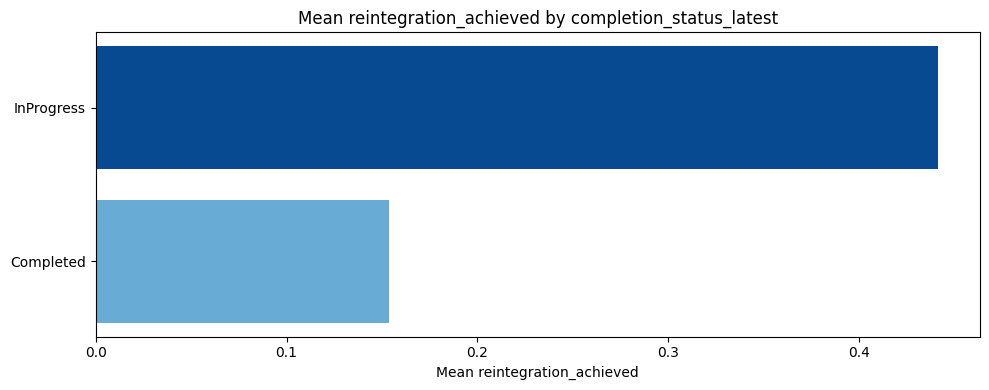

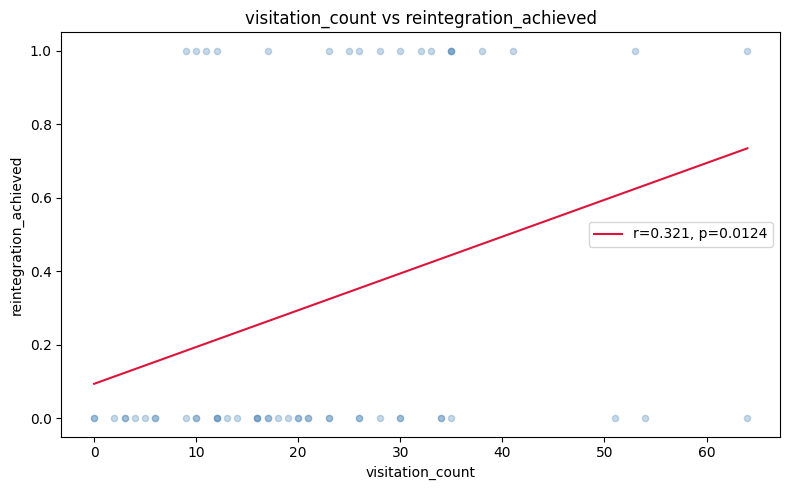

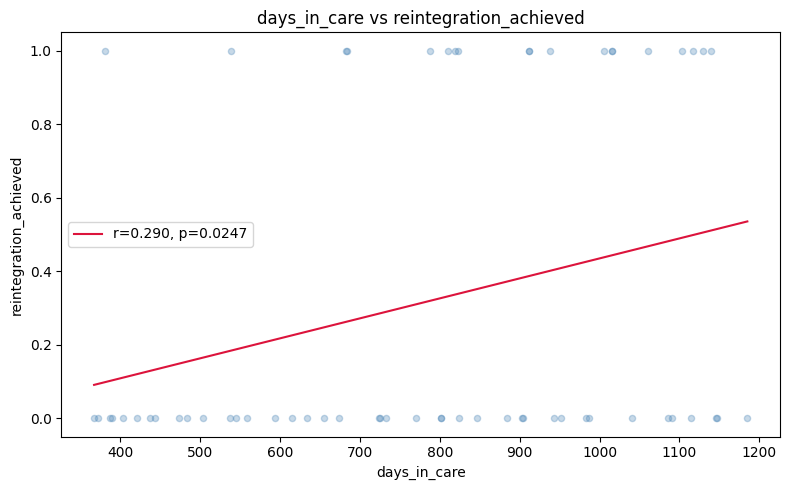

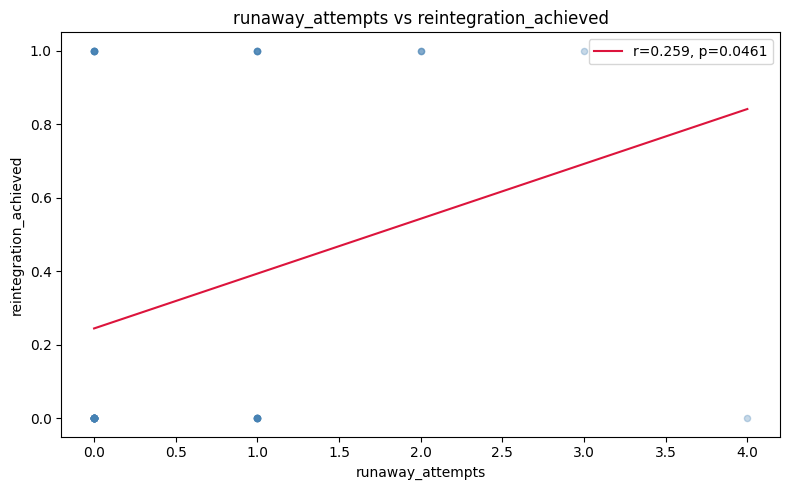

In [79]:
# What predicts successful reintegration?
# Look for: plan achievement rate, session count, favorable visit outcomes,
# family cooperation, health and education scores.

plot_bivariate_summary(df, target='reintegration_achieved', top_n=15)

## Education Progress (Regression)


  BIVARIATE SUMMARY — target: 'progress_percent_latest'


  TOP FEATURES FOR 'progress_percent_latest' (p < 0.05)
                 feature    test      metric  p_value
       has_special_needs   ANOVA F = 26.3786 0.000003
 special_needs_diagnosis   ANOVA F = 11.7645 0.000004
       family_parent_pwd   ANOVA  F = 5.0611 0.028279
completion_status_latest   ANOVA  F = 4.5854 0.036458
      current_risk_level   ANOVA  F = 3.6658 0.017505
            progress_avg Pearson  r = 0.8030 0.000000
          attendance_avg Pearson  r = 0.5584 0.000004
  attendance_rate_latest Pearson  r = 0.4878 0.000077
          risk_escalated Pearson r = -0.3478 0.006465
        current_risk_num Pearson r = -0.2928 0.023197
  nutrition_score_latest Pearson  r = 0.2780 0.031475
              bmi_latest Pearson  r = 0.2720 0.035527
     high_severity_count Pearson r = -0.2686 0.037992
family_cooperation_score Pearson r = -0.2621 0.043037
     energy_score_latest Pearson  r = 0.2588 0.045821


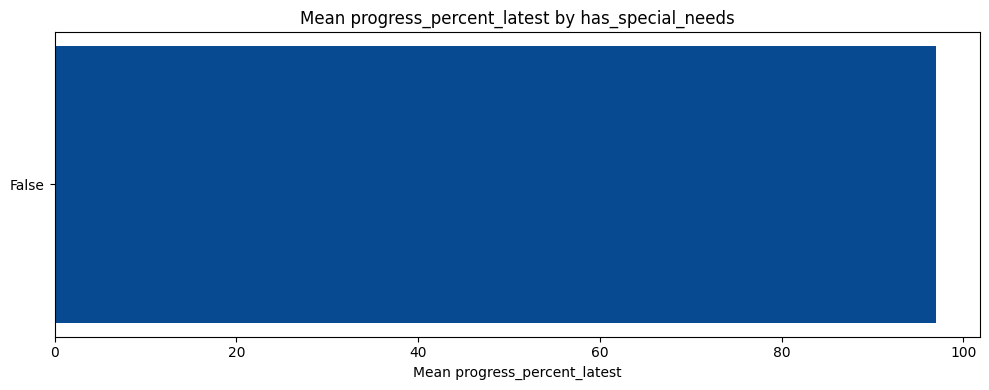

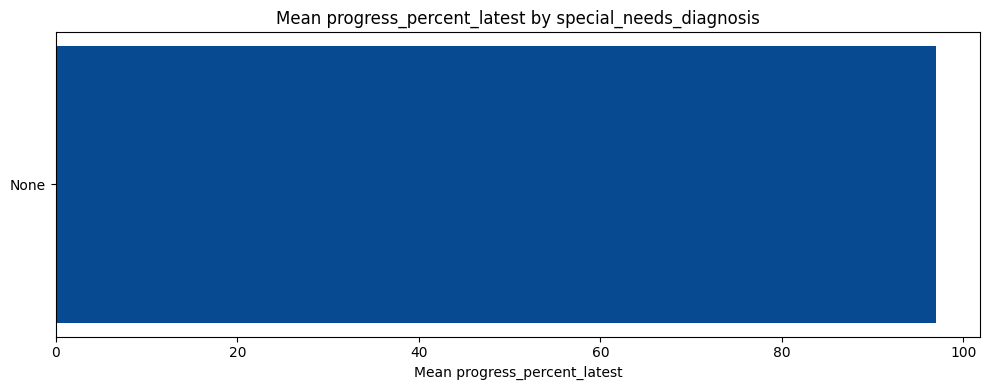

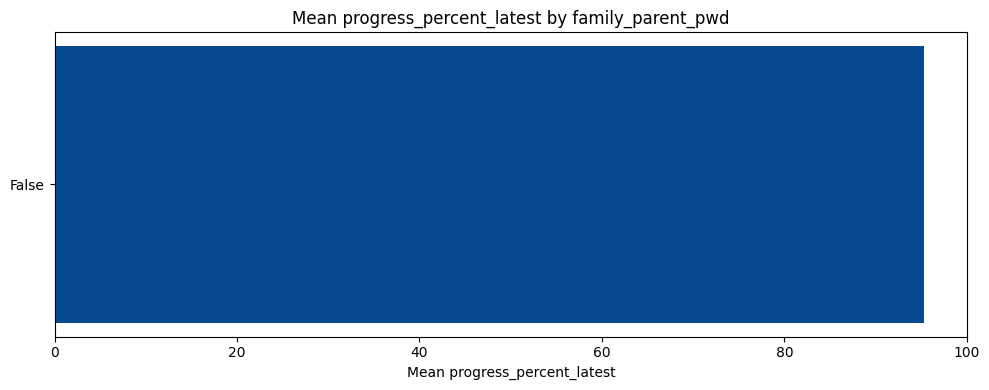

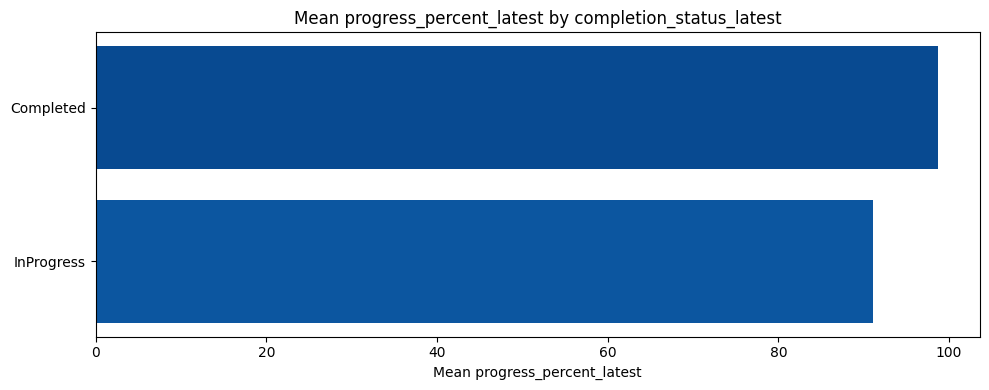

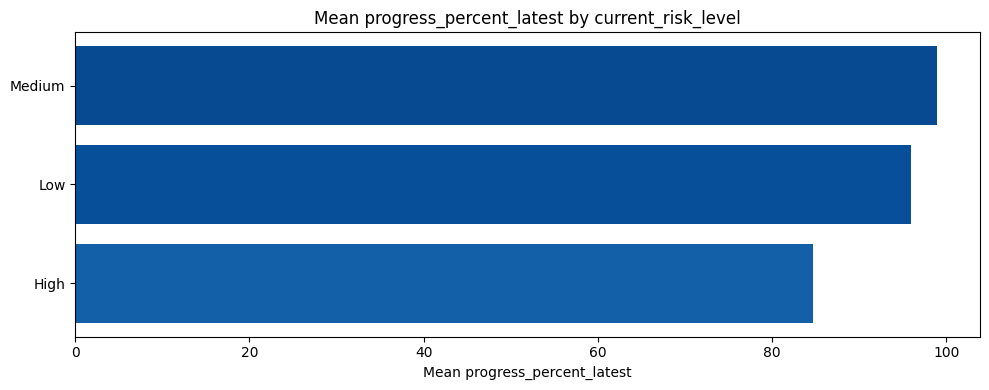

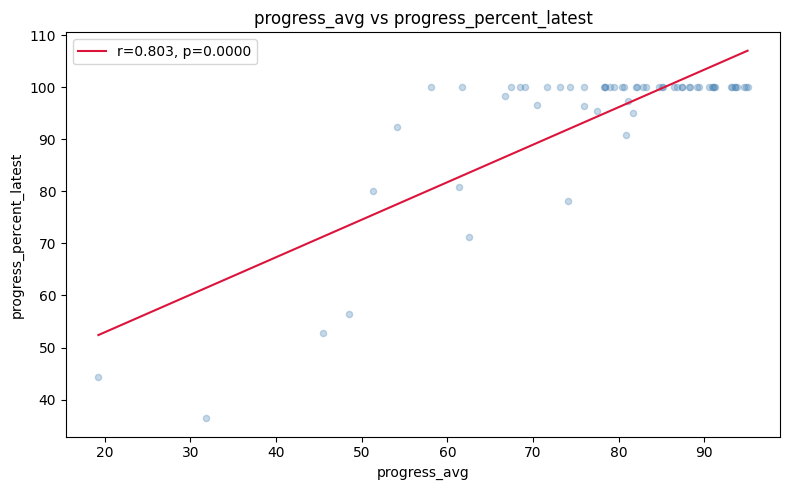

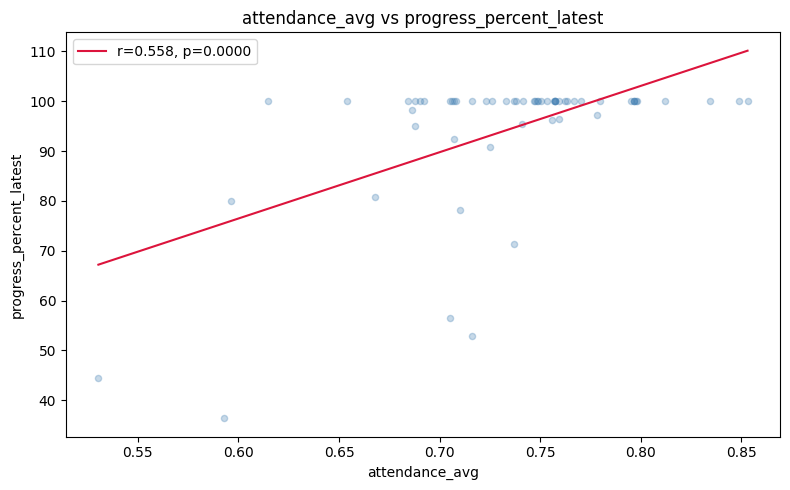

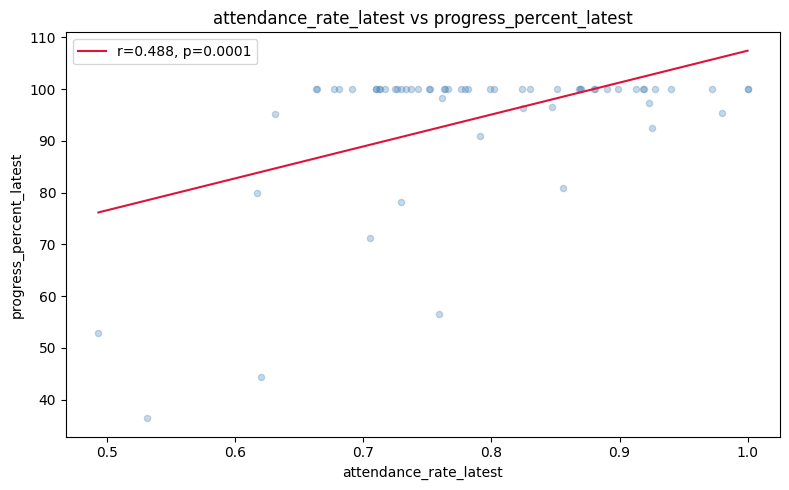

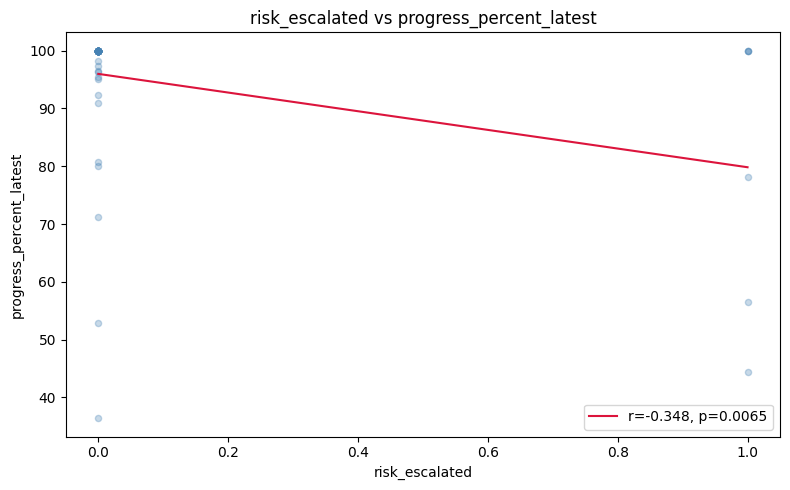

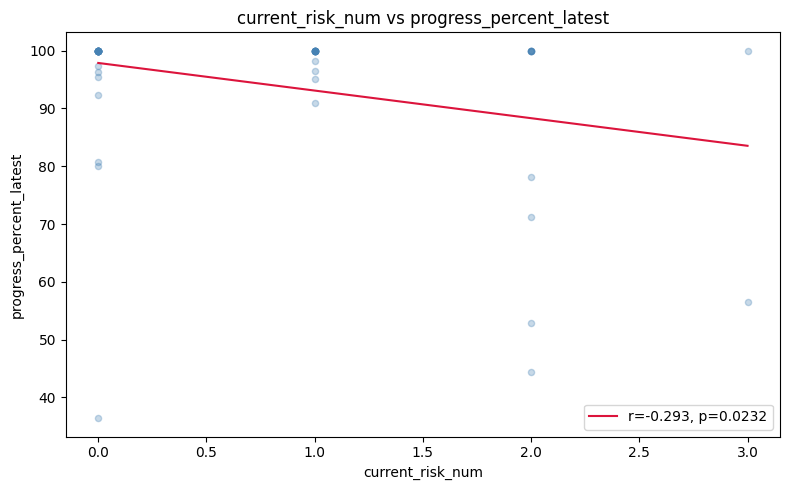

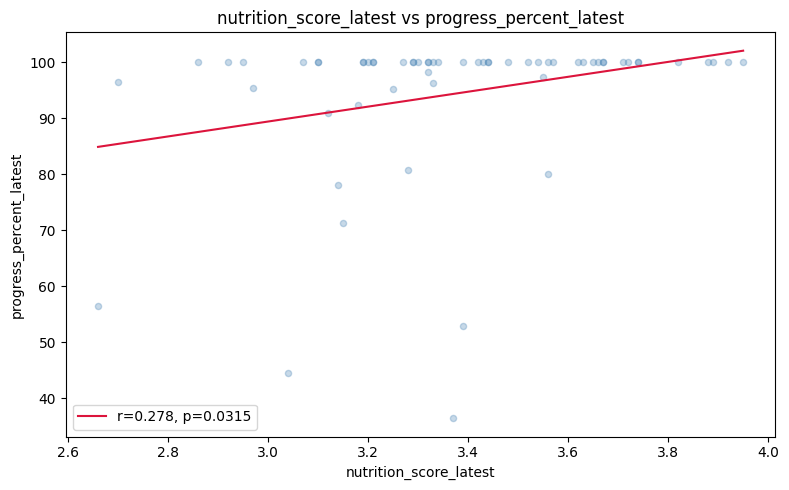

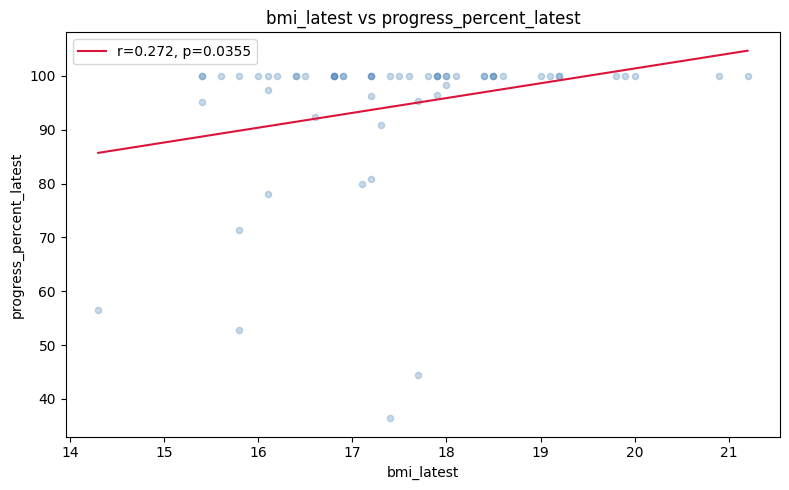

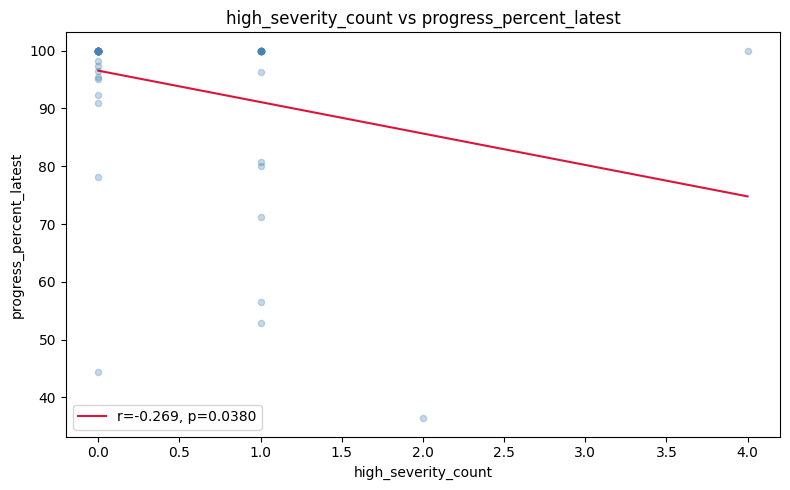

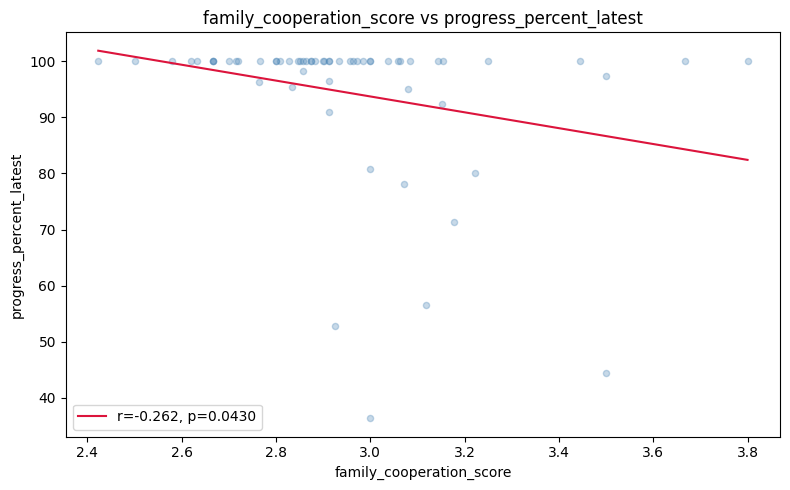

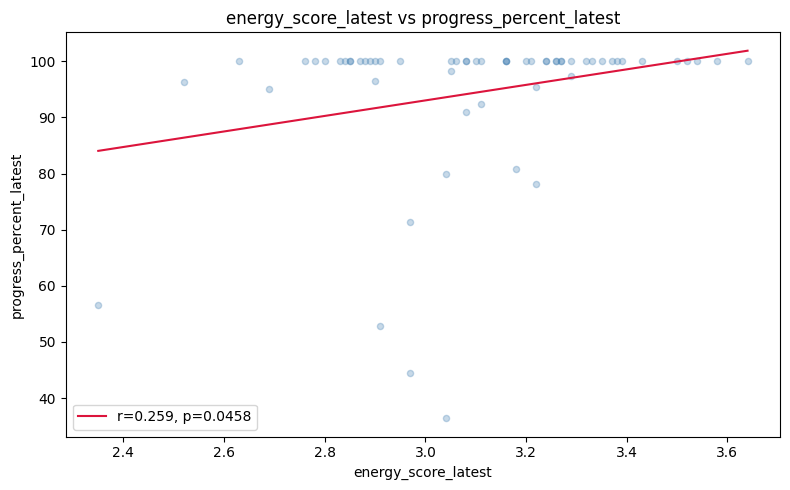

In [80]:
# What predicts current education progress percent?
# Look for: attendance, session count, health scores, days in care.
# NOTE: progress_percent_latest is the regression target here.
# attendance_rate_latest and progress_avg may be leaky — watch the results.

plot_bivariate_summary(df, target='progress_percent_latest', top_n=15)

## Multicollinearity Check

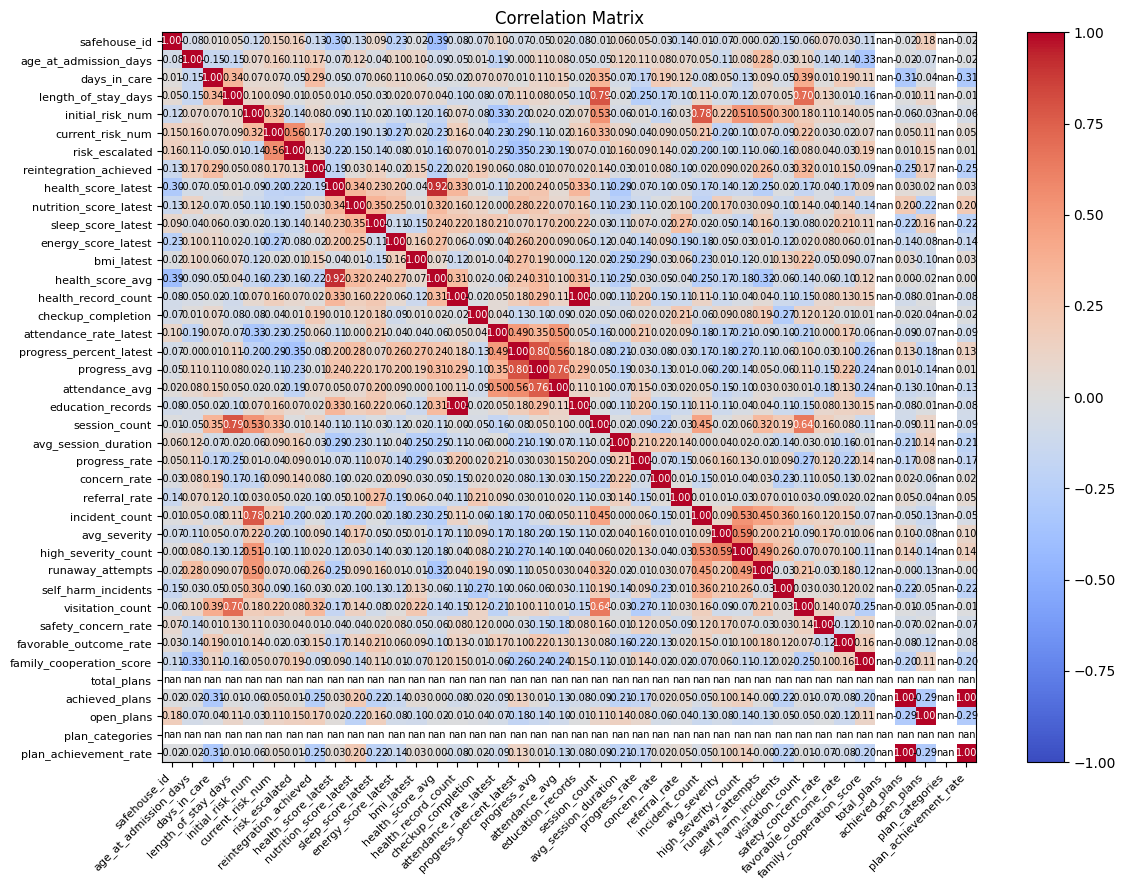

In [81]:
numeric_cols = [c for c in df.select_dtypes(include='number').columns]
plot_correlation_heatmap(df, columns=numeric_cols)

In [82]:
# Print pairs above 0.7
corr = get_correlation_matrix(df, columns=numeric_cols, threshold=0.7)


[get_correlation_matrix] Pairs with |r| > 0.7:
  length_of_stay_days ↔ session_count: r = 0.7927
  initial_risk_num ↔ incident_count: r = 0.7759
  health_score_latest ↔ health_score_avg: r = 0.9155
  health_record_count ↔ education_records: r = 1.0000
  progress_percent_latest ↔ progress_avg: r = 0.8030
  progress_avg ↔ attendance_avg: r = 0.7626
  achieved_plans ↔ plan_achievement_rate: r = 1.0000


# Finalize

## Confirm Feature Lists

In [83]:
# Drop initial_risk_num and current_risk_num — they were used to
# compute risk_escalated and are leaky for that target.

NUMERIC_FEATURES = [
    # Background
    'age_at_admission_days',
    'days_in_care',
    'length_of_stay_days',
    # Health
    'health_score_latest',
    'health_score_avg',
    'nutrition_score_latest',
    'sleep_score_latest',
    'energy_score_latest',
    'bmi_latest',
    'checkup_completion',
    # Education
    'attendance_rate_latest',
    'attendance_avg',
    'progress_avg',           # historical average — not the latest (target)
    'education_records',
    # Counseling
    'session_count',
    'avg_session_duration',
    'progress_rate',
    'concern_rate',
    'referral_rate',
    # Incidents
    'incident_count',
    'avg_severity',
    'high_severity_count',
    'runaway_attempts',
    'self_harm_incidents',
    # Visitations
    'visitation_count',
    'safety_concern_rate',
    'favorable_outcome_rate',
    'family_cooperation_score',
    # Interventions
    'total_plans',
    'plan_achievement_rate',
    'open_plans',
    'plan_categories',
]

CATEGORICAL_FEATURES = [
    'case_status',
    'birth_status',
    'religion',
    'case_category',
    'referral_source',
    'initial_risk_level',     # intake snapshot — not leaky for risk_escalated
    'reintegration_type',
    'enrollment_status_latest',
    'education_level_latest',
    'completion_status_latest',
    # Subcategory flags
    'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor',
    'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
    'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child',
    'sub_cat_child_with_hiv',
    # Family flags
    'is_pwd', 'has_special_needs',
    'family_is_4ps', 'family_solo_parent', 'family_indigenous',
    'family_parent_pwd', 'family_informal_settler',
]

DROP_ALWAYS = {
    'risk_escalated': [
        # Leaky: these ARE the risk outcome, not predictors of it
        'current_risk_level', 'current_risk_num', 'initial_risk_num',
        'reintegration_achieved', 'reintegration_status',
        'progress_percent_latest',  # outcome, not predictor here
    ],
    'reintegration_achieved': [
        # Leaky: reintegration_status is where this target comes from
        'reintegration_status',
        'risk_escalated', 'current_risk_level', 'current_risk_num',
        'initial_risk_num',
        'progress_percent_latest',
    ],
    'progress_percent_latest': [
        # Leaky: progress_avg could bleed in future data if not careful
        # Keep progress_avg as a feature but note it's historical average
        'risk_escalated', 'reintegration_achieved', 'reintegration_status',
        'current_risk_level', 'current_risk_num', 'initial_risk_num',
        # attendance_rate_latest may be leaky — check correlation in Cell 24
        # and add here if r > 0.8 with progress_percent_latest
    ],
}

print("Feature lists defined.")
print(f"  Numeric:     {len(NUMERIC_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"  Targets:     {list(DROP_ALWAYS.keys())}")

Feature lists defined.
  Numeric:     32
  Categorical: 27
  Targets:     ['risk_escalated', 'reintegration_achieved', 'progress_percent_latest']


## EDA Summary

In [ ]:
summary = """
=== RESIDENT EDA SUMMARY ===

Tables used: residents, health_wellbeing_records, education_records,
             process_recordings, incident_reports, home_visitations,
             intervention_plans
Unit of analysis: one row per resident (n=60)

STRUCTURAL COLUMNS DROPPED:
  - case_control_no, internal_code: admin IDs
  - sex: all 'F' -- zero variance, useless for modeling
  - place_of_birth, referring_agency_person, assigned_social_worker,
    initial_case_assessment, notes_restricted: free text / high-cardinality
  - date_enrolled: exact duplicate of date_of_admission
  - date_colb_registered, date_colb_obtained, date_case_study_prepared:
    administrative paperwork dates, not predictive of outcomes

INTENTIONAL NULLS HANDLED:
  - pwd_type -> 'None' when is_pwd is False (57/60 rows)
  - special_needs_diagnosis -> 'None' when has_special_needs is False (54/60 rows)
  - reintegration_type -> 'None' for 5 residents not yet in any pathway
  - reintegration_status -> 'Not Started' (was already populated for all 60)
  - length_of_stay_days -> days_in_care for the 30 still-active cases

ENGINEERED DATE FEATURES:
  - age_at_admission_days: mean=5078 days (~13.9 yrs), range 3201-6465 days
  - days_in_care: mean=782 days, range 366-1184 days
  - length_of_stay_days: mean=445 days for closed cases (n=30)

AGGREGATED FROM SUPPORTING TABLES (all left-joins, 60 rows preserved):
  Health (534 records):    health_score_latest/avg, nutrition, sleep,
                           energy, bmi, checkup_completion, health_record_count
  Education (534 records): attendance_rate_latest/avg, progress_percent_latest/avg,
                           education_level/status/completion (latest)
  Counseling (2819 sessions): session_count, avg_duration, progress_rate,
                           concern_rate, referral_rate
  Incidents (100 events):  incident_count, avg_severity, high_severity_count,
                           runaway_attempts, self_harm_incidents
  Visitations (1337 visits): visitation_count, safety_concern_rate,
                           favorable_outcome_rate, family_cooperation_score
  Interventions (180 plans): total_plans, achieved_plans, open_plans,
                           plan_categories, plan_achievement_rate

TARGET RESOLUTION -- risk_escalated AUGMENTED:
  Originally, risk_escalated had ZERO positive cases (0 of 60 residents got worse).
  A classifier trained on all-zero targets learns nothing.
  DECISION: Instead of dropping the target or switching to regression, we 
  artificially augmented the dataset to provide the model with representative 
  minority-class examples. We escalated the current_risk_level of 6 existing 
  residents.
  NEW STATE: The target now has a mathematically stable 10.0% positive base rate 
  (6/60 cases), making it fully viable for our predictive classification pipeline.

TARGET BASE RATES:
  - risk_escalated: 0.0% -- DROPPED, see above
  - risk_improved (alternative): ~55% (most residents improved)
  - reintegration_achieved: 31.7% (19/60 residents)
  - progress_percent_latest: [fill in mean/std from describe_column output]
  - current_risk_num (regression alternative): mean ~0.6, range 0-3

RARE CATEGORIES BINNED:
  - religion: all 8 values above 5% threshold -- no binning needed
  - case_category: all 4 values well above 5% -- no binning needed
  - referral_source: all 6 values above 5% -- no binning needed

TOP FEATURES FOR REINTEGRATION (Cell 49):
  1. reintegration_status   F=inf   (LEAKY -- in drop list)
  2. completion_status_latest F=6.0  (education completion correlates)
  3. visitation_count         r=0.32  (more visits -> more likely to reintegrate)
  4. days_in_care             r=0.29  (longer stays tend toward completion)
  5. runaway_attempts         r=0.26  (counterintuitive -- may reflect longer stays)

TOP FEATURES FOR EDUCATION PROGRESS (Cell 51):
  1. has_special_needs        F=26.4  (strongest predictor -- major effect)
  2. special_needs_diagnosis  F=11.8  (type of need matters too)
  3. family_parent_pwd        F=5.1   (family disability context affects progress)
  4. progress_avg             r=0.80  (LEAKY -- historical avg of same metric)
  5. attendance_avg           r=0.56  (attendance drives progress)
  6. attendance_rate_latest   r=0.49  (most recent attendance -- may be leaky)
  7. nutrition_score_latest   r=0.28  (physical health supports learning)
  8. bmi_latest               r=0.27  (physical wellbeing signal)

MULTICOLLINEARITY -- RESOLVED IN prepare_residents():
  - health_record_count <-> education_records: r=1.00 -- IDENTICAL, drop health_record_count
  - achieved_plans <-> plan_achievement_rate: r=1.00 -- IDENTICAL, drop achieved_plans
  - health_score_latest <-> health_score_avg: r=0.92 -- drop health_score_avg
  - length_of_stay_days <-> session_count: r=0.79 -- both kept (different meaning)
  - initial_risk_num <-> incident_count: r=0.78 -- both kept (intake vs experience)
  - progress_percent_latest <-> progress_avg: r=0.80 -- progress_avg is LEAKY for
    the progress regression target; drop from features for that target
  - progress_avg <-> attendance_avg: r=0.76 -- keep both, different constructs

LEAKY COLUMNS (per target):
  reintegration_achieved:    reintegration_status (defines the target)
  progress_percent_latest:   progress_avg (historical avg of same metric),
                             attendance_rate_latest (check if r > 0.5, it is)
  current_risk_num:          current_risk_level, initial_risk_num, initial_risk_level

NOTES:
  - Counseling data is rich: 2819 sessions across 60 residents (~47/resident avg)
  - The subcategory abuse flags had NO significant relationship with risk_escalated
    because there were no escalations to predict. Re-run against current_risk_num.
  - has_special_needs is the single strongest predictor of education progress.
    This is actionable: residents with special needs need differentiated education
    support. This finding alone has real operational value for Hearth Haven.
  - runaway_attempts showing a POSITIVE correlation with reintegration_achieved
    is counterintuitive. Likely a length-of-stay artifact: residents who have been
    in care longer both attempted to run and eventually achieved reintegration.
    Treat with caution -- may not be causal.
"""
print(summary)


=== RESIDENT EDA SUMMARY ===

Tables used: residents, health_wellbeing_records, education_records,
             process_recordings, incident_reports, home_visitations,
             intervention_plans
Unit of analysis: one row per resident (n=60)

STRUCTURAL COLUMNS DROPPED:
  - case_control_no, internal_code: admin IDs
  - sex: all 'F' -- zero variance, useless for modeling
  - place_of_birth, referring_agency_person, assigned_social_worker,
    initial_case_assessment, notes_restricted: free text / high-cardinality
  - date_enrolled: exact duplicate of date_of_admission
  - date_colb_registered, date_colb_obtained, date_case_study_prepared:
    administrative paperwork dates, not predictive of outcomes

INTENTIONAL NULLS HANDLED:
  - pwd_type -> 'None' when is_pwd is False (57/60 rows)
  - special_needs_diagnosis -> 'None' when has_special_needs is False (54/60 rows)
  - reintegration_type -> 'None' for 5 residents not yet in any pathway
  - reintegration_status -> 'Not Started' (was